<>:55: SyntaxWarning: invalid escape sequence '\M'
<>:55: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_674/2029561584.py:55: SyntaxWarning: invalid escape sequence '\M'
  print("\Model Evaluation")


Training samples: (25000, 200)
Testing samples: (25000, 200)

Model Architecture


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7637 - loss: 0.4731 - val_accuracy: 0.8512 - val_loss: 0.3441
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8972 - loss: 0.2599 - val_accuracy: 0.8772 - val_loss: 0.3083
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9272 - loss: 0.1901 - val_accuracy: 0.8606 - val_loss: 0.3700
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9475 - loss: 0.1463 - val_accuracy: 0.8684 - val_loss: 0.3721
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9654 - loss: 0.0986 - val_accuracy: 0.8648 - val_loss: 0.4421


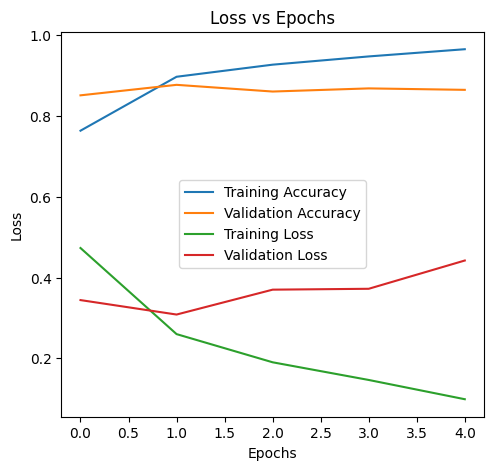

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8600 - loss: 0.4539
\Model Evaluation
Test Loss: 0.4538858234882355
Test Accuracy: 0.8600000143051147
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


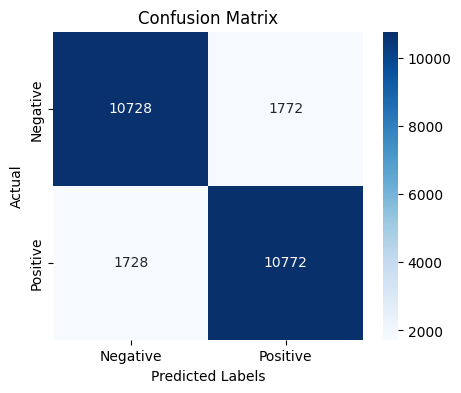


Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



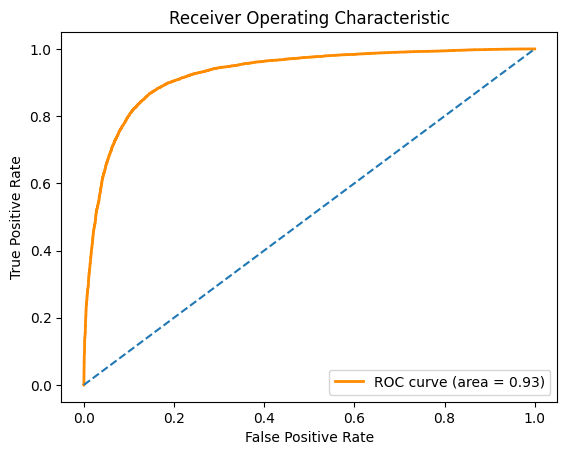


Prediction Interpretation

Review 1
Actual Sentiment : Negative
Predicted Sentiment: Negative
Prediction Confidence: 0.129
----------------------------------------
Review 2
Actual Sentiment : Positive
Predicted Sentiment: Positive
Prediction Confidence: 1.0
----------------------------------------
Review 3
Actual Sentiment : Positive
Predicted Sentiment: Negative
Prediction Confidence: 0.316
----------------------------------------
Review 4
Actual Sentiment : Negative
Predicted Sentiment: Positive
Prediction Confidence: 0.991
----------------------------------------
Review 5
Actual Sentiment : Positive
Predicted Sentiment: Positive
Prediction Confidence: 1.0
----------------------------------------


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

vocab_size = 10000
max_len = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Training samples:",x_train.shape)
print("Testing samples:",x_test.shape)

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nModel Architecture")
print(model.summary())

history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test)

print("\Model Evaluation")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

predictions = model.predict(x_test)
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual")
plt.show()


print("\nClassification Report")
print(classification_report(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.show()

print("\nPrediction Interpretation\n")
for i in range(5):
  prob = predictions[i][0]
  predicted_sentiment = "Positive" if prob > 0.5 else "Negative"
  actual_sentiment = "Positive" if y_test[i] == 1 else "Negative"
  print(f"Review {i+1}")
  print("Actual Sentiment :", actual_sentiment)
  print("Predicted Sentiment:", predicted_sentiment)
  print("Prediction Confidence:", round(prob,3))
  print("-"*40)